# How Basener and Sanford Got Their Results

In Section 5.4, Basener and Sanford give an incomplete and misleading account of selectively reported results. They indicate that thresholding of frequencies, putatively for the sake of "biological realism," is the critical factor in their observation of a "crashing" population. We will establish they managed to produce the result only by introducing an additional gimmick, unreported in the paper, for greatly reducing the fraction of mutations that have no effect on fitness. That is, when we eliminate either the frequency threshold or the unreported gimmick, and leave all else the same, the population grows rather than shrinks in size.

The gimmick is addressed in detail elsewhere in this binder. Here it suffices to say that Basener's code (excerpted in [BS.js](../Code/BS.js)) sets the probabilty of zero mutation effect to the probability of minimally deleterious effect. The latter is much smaller than the former, and Basener's code ends up with probabilities that sum to about .82. This means that the birth rates for all types of organism are effectively 82 percent of the birth rates that Basener and Sanford report.

In [1]:
%matplotlib notebook
%run ../Code/bs.py

## Defining the distributions

We set up the initial frequency distribution for all runs, and also two versions of the distribution over mutation effects. Let's take care of the initial frequency distribution immediately.

In [2]:
factors = Factors(N_TYPES['Gamma'])
initial = GaussianFrequencies(factors)

Basener's script features not only a gimmick to reduce the probability that mutation is neutral in effect, but also a grossly erroneous reweighting of the distribution. The reweighting is supposed to make the probability that mutation is positive in effect equal to .001. It instead makes the norm of the distribution (sum of all probabilities) equal to .82, and associates probability mass of 0.00062 with beneficial mutations. Put simply, Basener's script silently kills many of the births, and greatly reduces the incidence of beneficial mutation in the births it does not kill.

Basener and Sanford did not need the botched reweighting to obtain the "crashing" population of Section 5.4. Here we retain only the gimmick for reducing the probability that mutation has zero effect. You should read the comments in the following cell, if not the code, to gain an understanding of the operations we are about to perform.

In [3]:
# %load ../Code/gamma.py
class Gamma(EffectsDistribution):
    """
    A discretized Gamma distribution and its reflection in the zero-effect axis.
    """
    def __init__(self, factors, alpha=0.5, beta=0.5/0.001, density=True,
                       normed=False):
        """
        Defines a symmetric Gamma distribution with the given parameters.
        
        The `factors` object is an instance of class `Factors`. The Boolean
        parameters `density` and `normed` determine, respectively, whether the
        density function or the cumulative distribution function is used in
        assignment of probability masses to effects, and whether the resulting
        distribution is normalized.
        """
        rv = stats.gamma(alpha, scale=1/beta)
        super().__init__(factors, rv, density=density, normed=normed)
        
    def gimmick(self):
        """
        Assigns the probability of minimally deleterious effect to zero effect.
        """
        effect = self.domain
        self.p[effect == 0] = self.p[effect < 0][-1]

    def reweight(self, beneficial=0.001, botched=False):
        """
        Sets the probability of positive effect to `beneficial` unless botched.
        
        If `botched` is false, then the probabilities of positive mutation
        effects are scaled so that they sum to `beneficial`, and the
        probabilities of non-positive effects are scaled so that they sum to
        1 - `beneficial`.
        
        If `botched` is true, then the probabilities of positive and non-
        positive effects are simply multiplied by `beneficial` and 1 -
        `beneficial`, respectively.
        """
        effect = self.domain
        if not botched:
            self.p[effect > 0] /= fsum(self.p[effect > 0])
            self.p[effect <= 0] /= fsum(self.p[effect <= 0])
        self.p[effect > 0] *= beneficial
        self.p[effect <= 0] *= 1 - beneficial

In [4]:
no_gimmick = Gamma(factors)
no_gimmick.reweight(botched=False)

gimmick = Gamma(factors)
gimmick.gimmick()
gimmick.reweight(botched=False)

### Plot of the distributions of probability over mutation effects



<IPython.core.display.Javascript object>


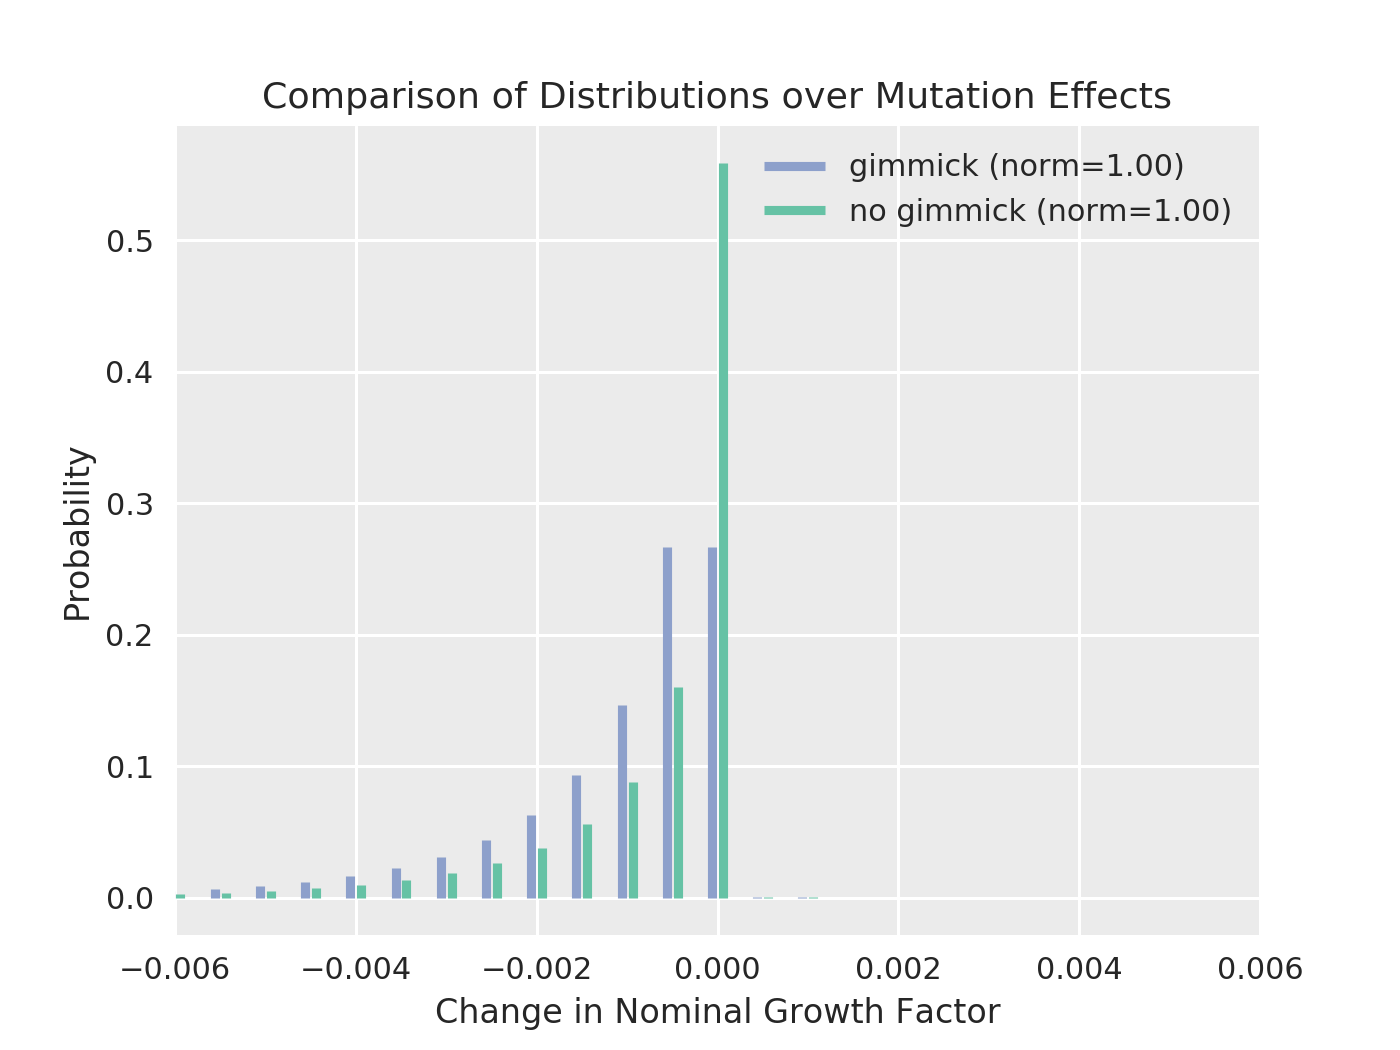

In [5]:
fig, ax = plt.subplots()
ax.set_title('Comparison of Distributions over Mutation Effects')
ax.set_xlim(-0.006, 0.006)
offset = 0.00006
label = 'gimmick (norm={0:.2f})'.format(gimmick.norm())
gimmick.vlines(ax, -offset, label, sns.color_palette()[2])
label = 'no gimmick (norm={0:.2f})'.format(no_gimmick.norm())
no_gimmick.vlines(ax, offset, label, sns.color_palette()[0])
ax.legend();

## Defining the processes to be compared

We will compare three processes. The baseline process features both the gimmick and thresholding, i.e., zeroing of frequencies that are small in relation to the maximum of the frequencies. There are two alternative processes, each of which differs from the baseline in only one way.

In [6]:
baseline = Evolution(Population(initial, gimmick, norm=np.max, label='baseline'))
sans_gimmick = Evolution(Population(initial, no_gimmick, norm=np.max, label='no gimmick'))
sans_threshold = Evolution(Population(initial, gimmick, norm=None, label='no threshold'))
comparison = Comparison([sans_threshold, sans_gimmick, baseline])
comparison.set_subtitle('\nB&S Need Both Gimmick and Threshold')
comparison(2500)

## Graphical comparison of baseline and alternative processes

Now we generate a grahical comparison of the three processes. With the number of frames (`nframes`) set to zero in the following cell, a static figure is generated instead of an animation. If you are connected to a Jupyter server, then you should set `nframes` to a positive number. Start with a small number, e.g., 25, to get oriented. Use the `n_years` parameter to restrict the animation to the earlier years of the processes. With `n_years=None`, all years are included. The `duration` of the animation is specified in milliseconds.

In the display of proportions (normalized frequencies), the curve for "no threshold" is hidden behind that for the baseline process for about 650 years. It is important to observe how the frequencies are changing (in the upper frame) at the time that the proportions diverge (in the lower frame).

<IPython.core.display.Javascript object>


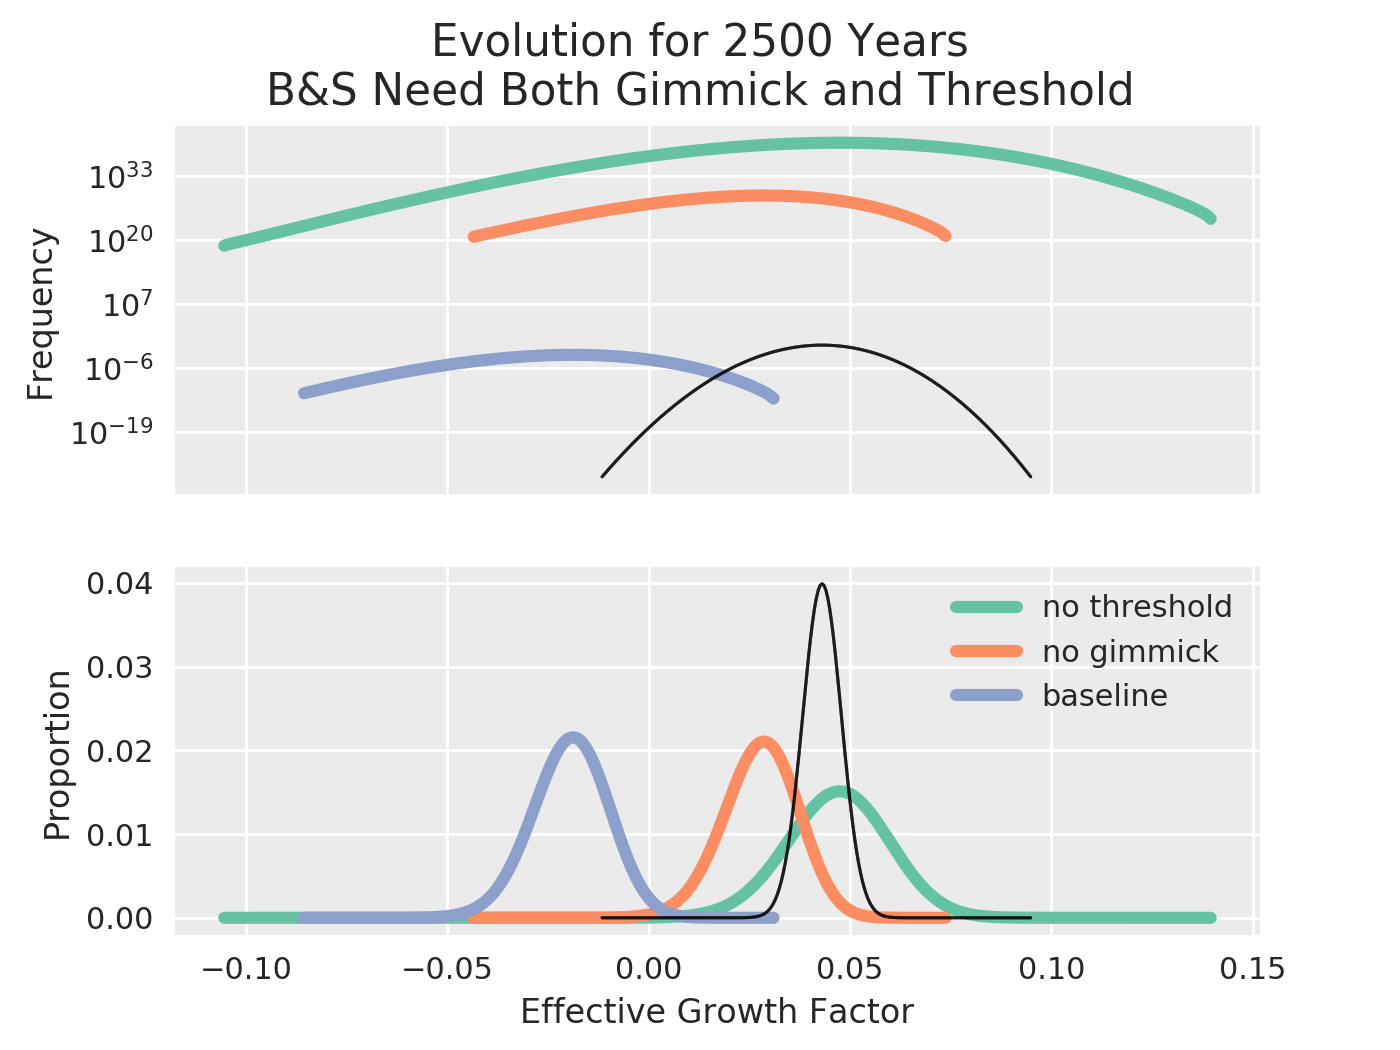

In [7]:
plt.rcParams['animation.embed_limit'] = 40 # megabytes
comparison.animate(nframes=0, duration=10000, effective=True, n_years=None)

The animation of three processes is at times visually confusing, so we also display pairwise comparisons of the alternative processes to the baseline process.

### Comparison of "no threshold" and baseline processes

<IPython.core.display.Javascript object>


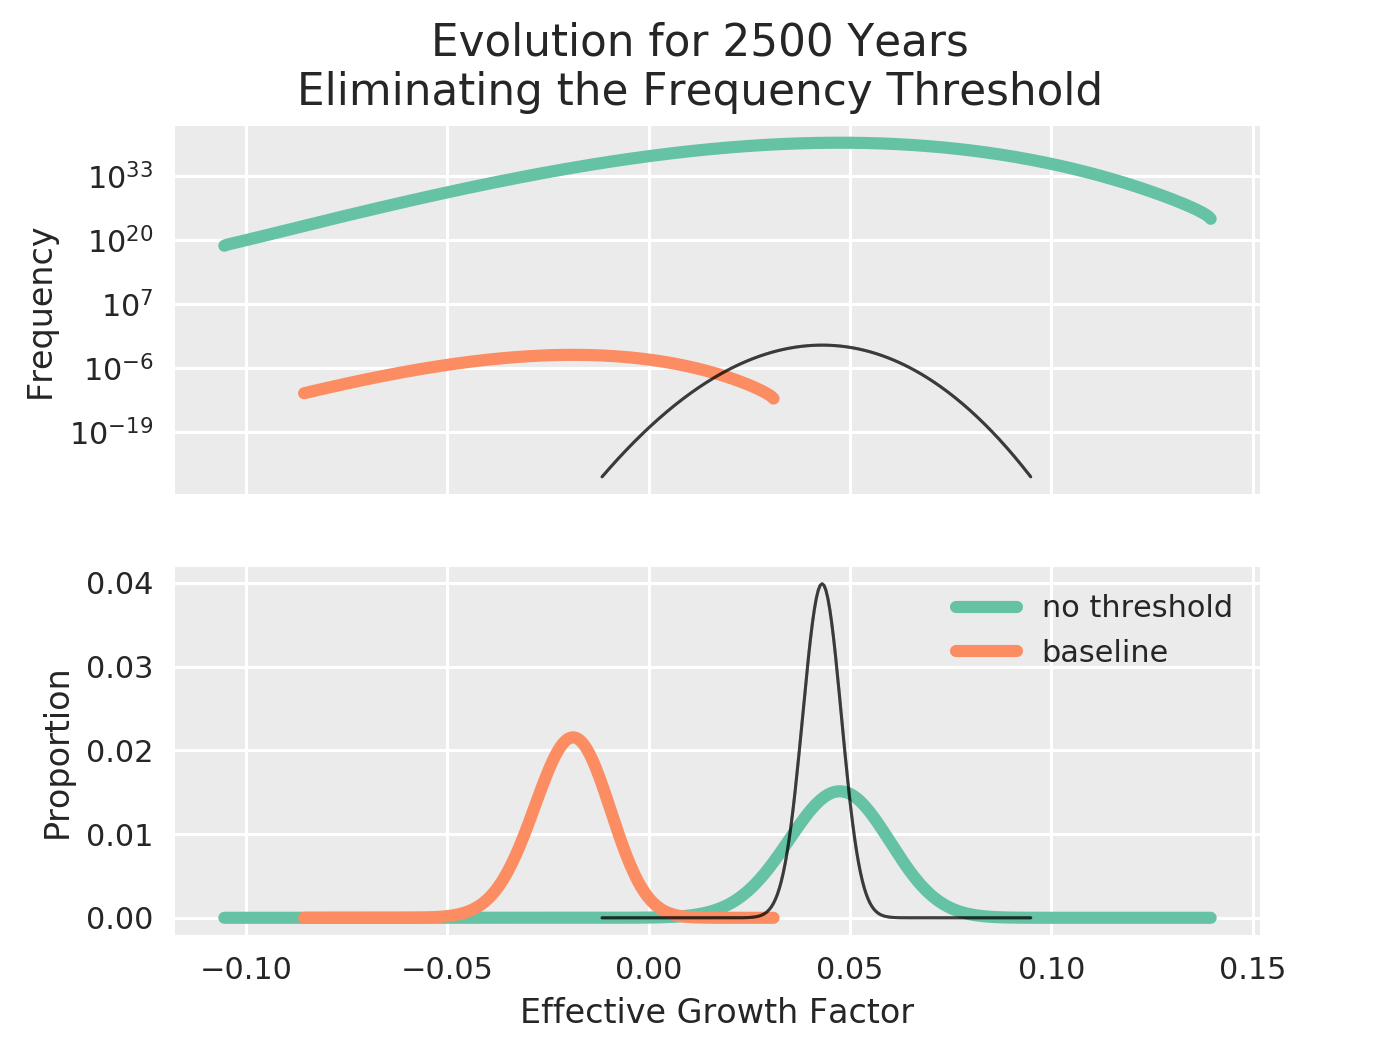

In [8]:
no_threshold_versus_bs = Comparison([sans_threshold, baseline])
no_threshold_versus_bs.set_subtitle('\nEliminating the Frequency Threshold')
no_threshold_versus_bs.animate(nframes=0, duration=10000, effective=True, n_years=None)

<IPython.core.display.Javascript object>


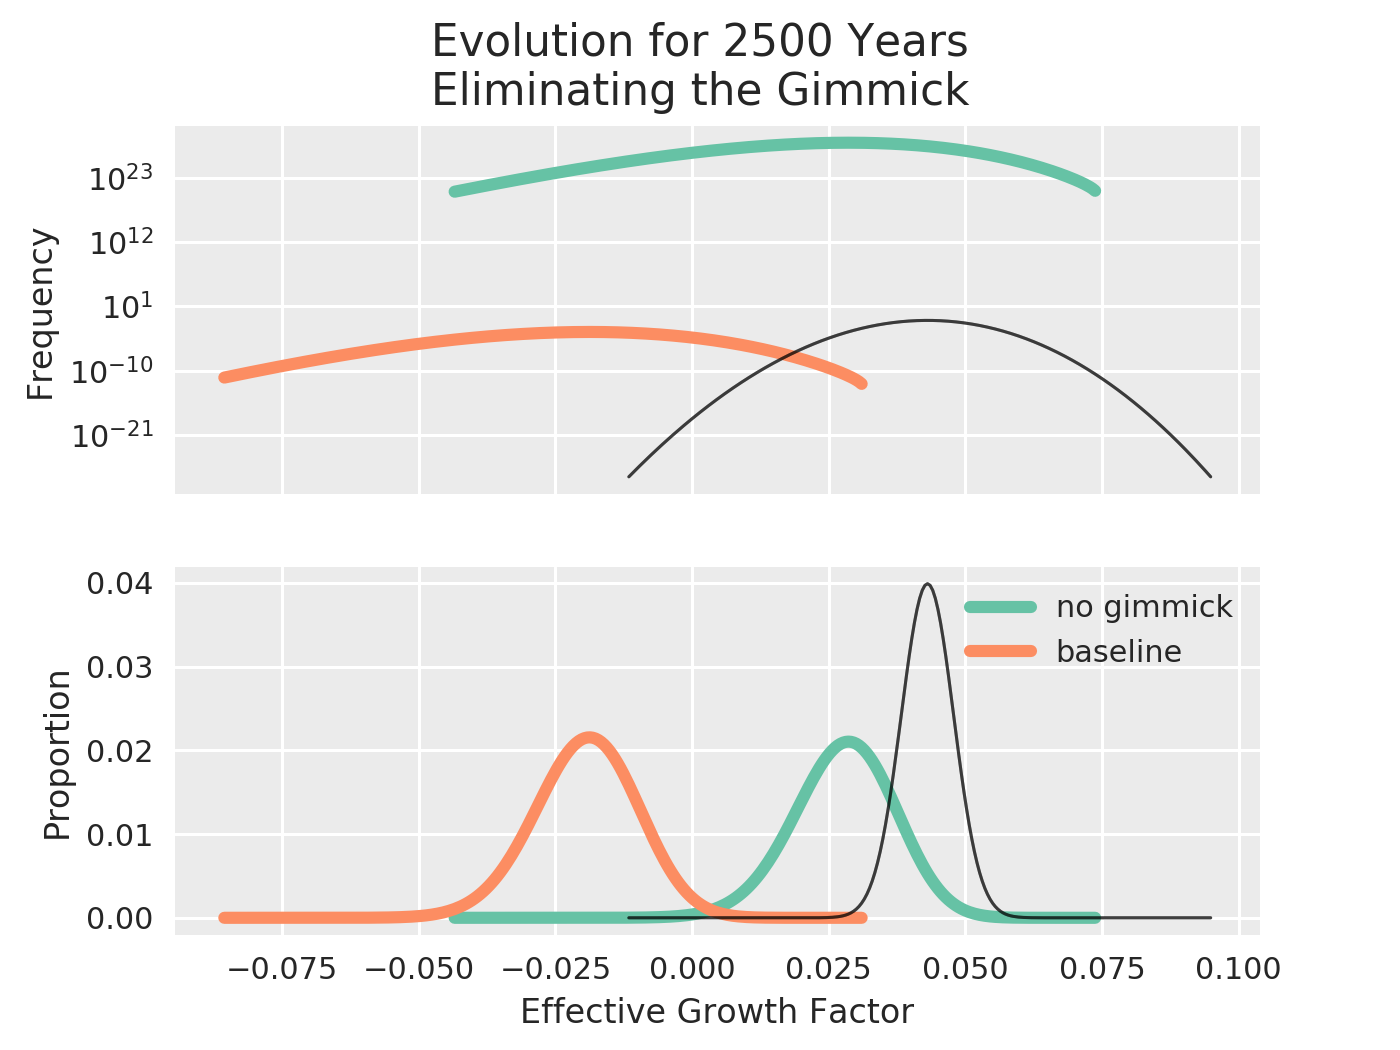

In [9]:
no_gimmick_versus_bs = Comparison([sans_gimmick, baseline])
no_gimmick_versus_bs.set_subtitle('\nEliminating the Gimmick')
no_gimmick_versus_bs.animate(nframes=0, duration=10000, effective=True, n_years=None)

## The botched process addressed in Section 5.4

Now we have a look at the process that Basener and Sanford address in Section 5.4. We start by generating a distribution that is not only gimmicked, but also botched in the reweighting.

In [10]:
botched = Gamma(factors)
botched.gimmick()
botched.reweight(botched=True)
botched_ev = Evolution(Population(initial, botched, norm=np.max, label='botched'), 2500)

Now we see the effect of botched reweighting on the distribution.

<IPython.core.display.Javascript object>


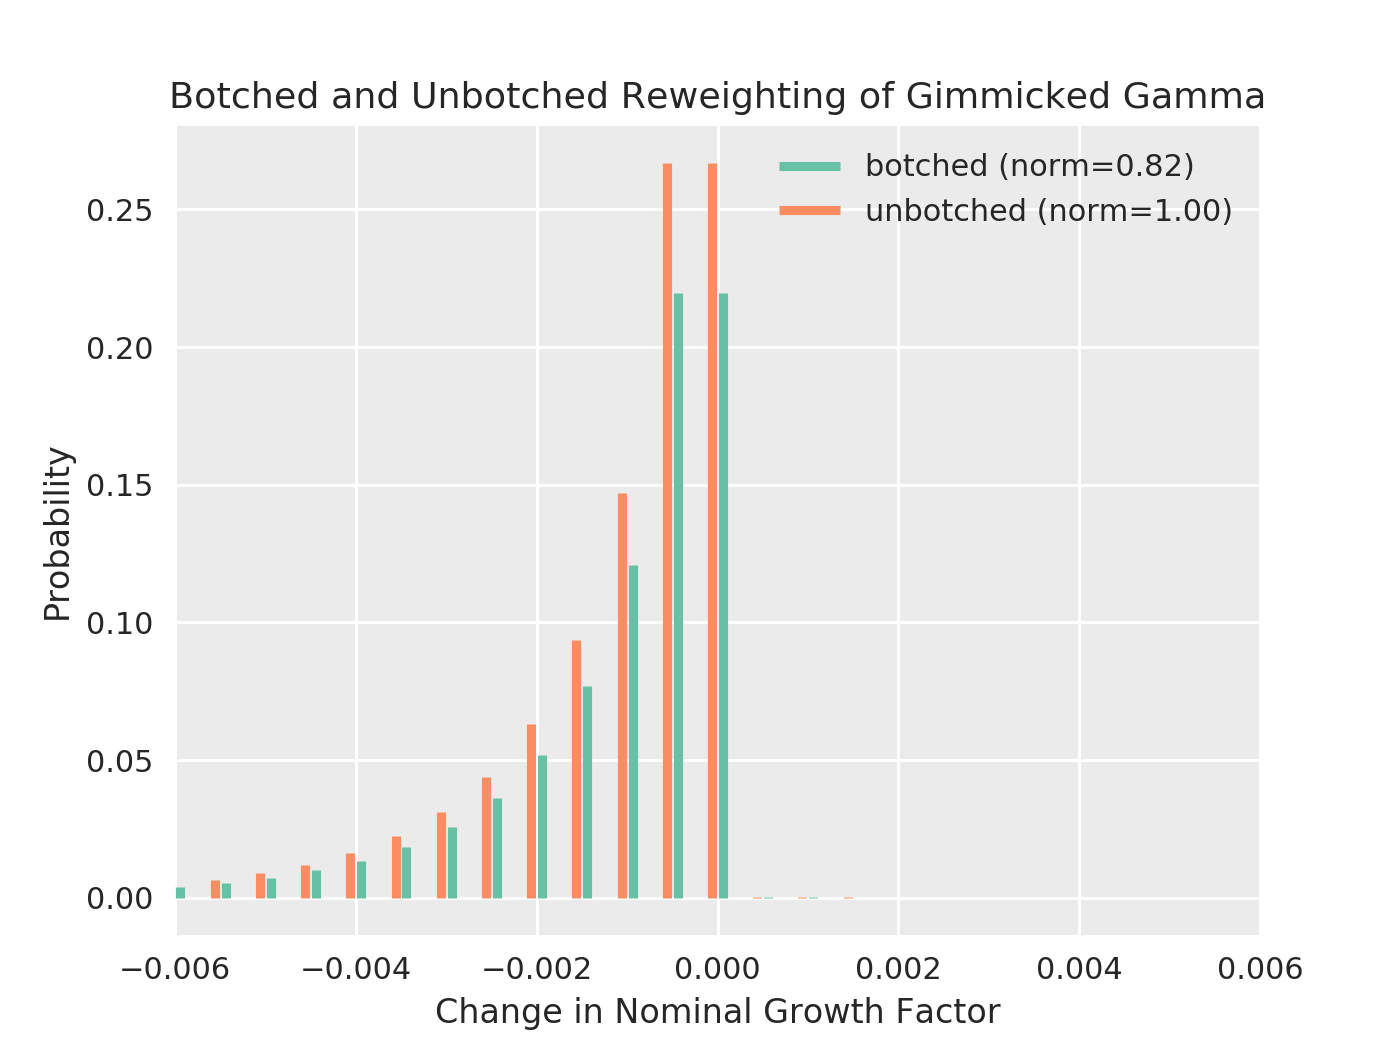

In [11]:
fig, ax = plt.subplots()
ax.set_title('Botched and Unbotched Reweighting of Gimmicked Gamma')
ax.set_xlim(-0.006, 0.006)
offset = 0.00006
label = 'botched (norm={0:.2f})'.format(botched.norm())
botched.vlines(ax, offset, label, sns.color_palette()[0])
label = 'unbotched (norm={0:.2f})'.format(gimmick.norm())
gimmick.vlines(ax, -offset, label, sns.color_palette()[1])
ax.legend();

When the norm of the distribution over mutation effects is 0.82, the birth factors are reduced by 18 percent.

<IPython.core.display.Javascript object>


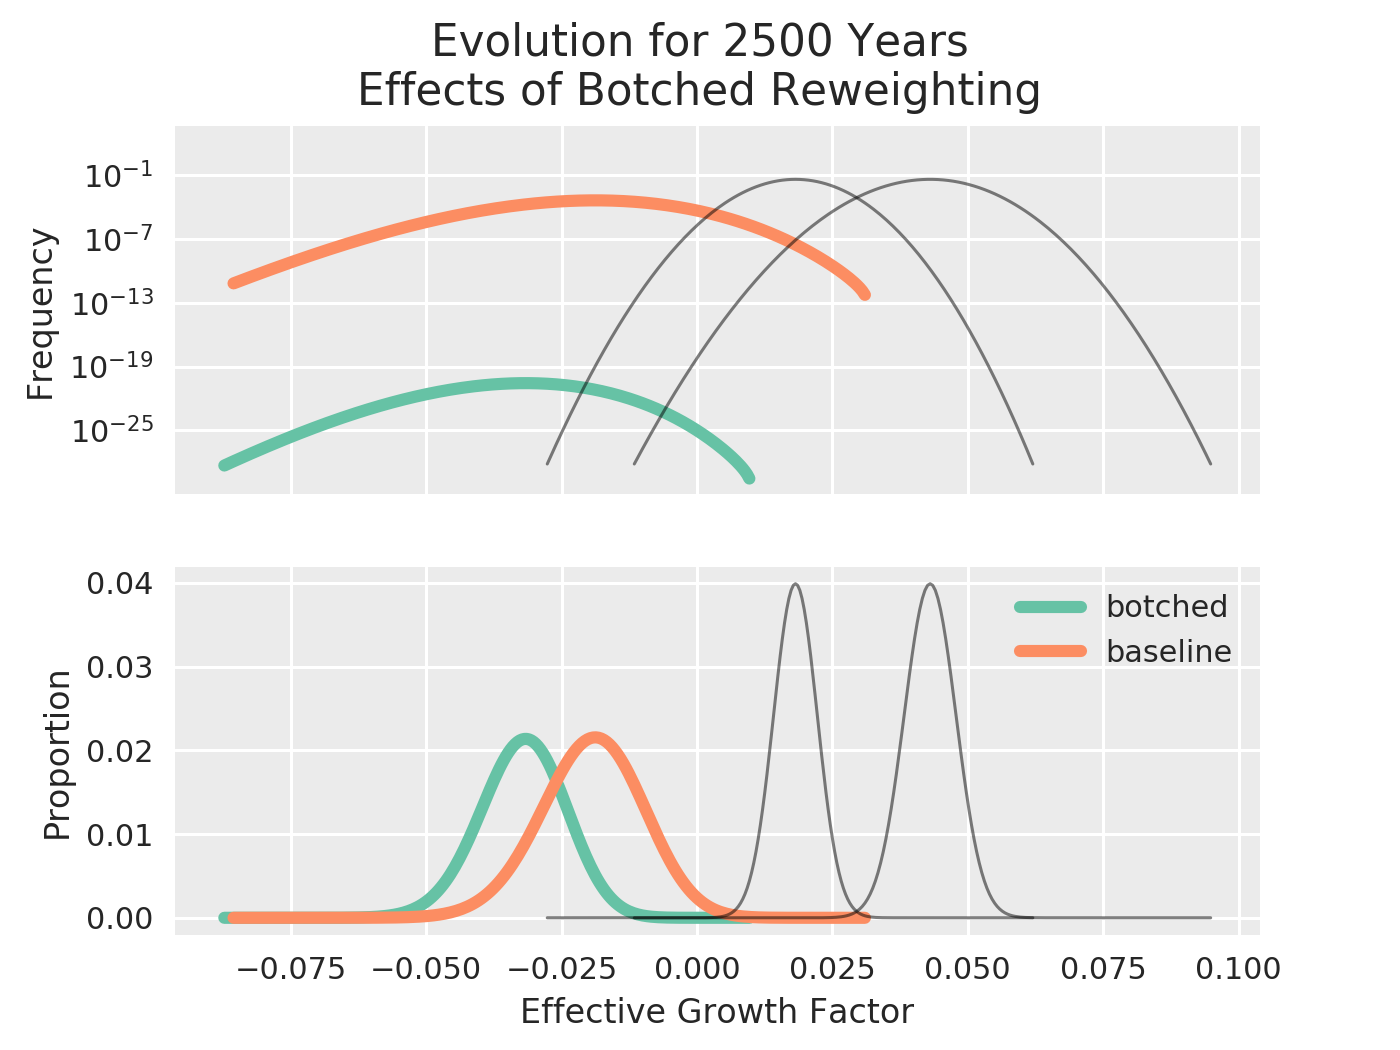

In [12]:
gimmick_versus_botched = Comparison([botched_ev, baseline])
gimmick_versus_botched.set_subtitle('\nEffects of Botched Reweighting')
gimmick_versus_botched.animate(nframes=0, duration=10000, effective=True, n_years=None)

## Conclusion

The results of Section 5.4 do not depend merely on the frequency threshold, as Basener and Sanford indicate, but also on an unreported gimmick for greatly reducing the probability that mutation has no effect on fitness. Neither the thresholding operation nor the gimmick alone results in the "crashing" population that Basener and Sanford report.